# Model Optimization and Hyperparameter Tuning

This notebook focuses on:
1. Cross-validation (5-fold)
2. Learning curves analysis
3. Grid Search for hyperparameter optimization
4. Model comparison and final selection

## 1. Import Libraries and Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [7]:
# Load cleaned data
print("="*80)
print("LOADING DATA")
print("="*80)

df = pd.read_csv('../data/cleaned/wine_data_cleaned.csv')

print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst rows:")
print(df.head())

LOADING DATA

Dataset shape: (54170, 12)
Columns: ['id', 'country', 'description', 'designation', 'points', 'price', 'province', 'primary_region', 'taster_name', 'title', 'variety', 'winery']

First rows:
   id country                                        description  \
0   3      US  Pineapple rind, lemon pith and orange blossom ...   
1   4      US  Much like the regular bottling from 2012, this...   
2   5   Spain  Blackberry and raspberry aromas show a typical...   
3   6   Italy  Here's a bright, informal red that opens with ...   
4   9  France  This has great depth of flavor with its fresh ...   

                          designation  points  price           province  \
0                Reserve Late Harvest      87   13.0           Michigan   
1  Vintner's Reserve Wild Child Block      87   65.0             Oregon   
2                        Ars In Vitro      87   15.0     Northern Spain   
3                             Belsito      87   16.0  Sicily & Sardinia   
4          

## 2. Data Preprocessing

In [8]:
print("\n" + "="*80)
print("DATA PREPROCESSING")
print("="*80)

# Define target and features
y = df['points']
X = df.drop(['points', 'id', 'description', 'title'], axis=1, errors='ignore')

print(f"\nTarget variable (y): {y.shape}")
print(f"Features (X): {X.shape}")

# Identify column types
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n📊 Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"📝 Categorical features ({len(categorical_features)}): {categorical_features}")


DATA PREPROCESSING

Target variable (y): (54170,)
Features (X): (54170, 8)

📊 Numeric features (1): ['price']
📝 Categorical features (7): ['country', 'designation', 'province', 'primary_region', 'taster_name', 'variety', 'winery']


In [9]:
# ============================================================
# ENCODING - VERSION OPTIMISÉE MÉMOIRE
# ============================================================

print("\n" + "="*80)
print("DATA PREPROCESSING - MEMORY EFFICIENT")
print("="*80)

# Define target and features
y = df['points']
X = df.drop(['points', 'id', 'description', 'title'], axis=1, errors='ignore')

print(f"\nTarget variable (y): {y.shape}")
print(f"Features (X): {X.shape}")

# Identify column types
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n📊 Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"📝 Categorical features ({len(categorical_features)}): {categorical_features}")

# Analyser la cardinalité
print(f"\n🔍 Analyzing cardinality:")
for col in categorical_features:
    n_unique = X[col].nunique()
    print(f"   {col:<20}: {n_unique:>6} unique values")

# ✅ STRATÉGIE MIXTE : LabelEncoder + OneHotEncoder sélectif
# LabelEncoder pour haute cardinalité (>100 valeurs)
# OneHotEncoder pour basse cardinalité (<100 valeurs)

high_cardinality = [col for col in categorical_features if X[col].nunique() >= 100]
low_cardinality = [col for col in categorical_features if X[col].nunique() < 100]

print(f"\n📋 Encoding strategy:")
print(f"   LabelEncoder ({len(high_cardinality)}): {high_cardinality}")
print(f"   OneHotEncoder ({len(low_cardinality)}): {low_cardinality}")

# Copier X
X_encoded = X.copy()

# 1. LabelEncoder pour haute cardinalité
from sklearn.preprocessing import LabelEncoder

print(f"\n🔹 Applying LabelEncoder...")
for col in high_cardinality:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    print(f"   ✓ {col}")

# 2. OneHotEncoder pour basse cardinalité uniquement
if low_cardinality:
    print(f"\n🔹 Applying OneHotEncoder...")

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_onehot = encoder.fit_transform(X_encoded[low_cardinality])
    onehot_feature_names = encoder.get_feature_names_out(low_cardinality)

    print(f"   Created {len(onehot_feature_names)} one-hot columns")

    # Créer DataFrame
    X_onehot_df = pd.DataFrame(X_onehot, columns=onehot_feature_names, index=X.index)

    # Supprimer les colonnes originales et ajouter les one-hot
    X_encoded = X_encoded.drop(columns=low_cardinality)

    # Concaténer progressivement pour économiser la mémoire
    X_encoded = pd.concat([X_encoded, X_onehot_df], axis=1)

print(f"\n✅ Encoding complete!")
print(f"   Before: {X.shape[1]} columns")
print(f"   After: {X_encoded.shape[1]} columns")
print(f"   Memory usage: {X_encoded.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


DATA PREPROCESSING - MEMORY EFFICIENT

Target variable (y): (54170,)
Features (X): (54170, 8)

📊 Numeric features (1): ['price']
📝 Categorical features (7): ['country', 'designation', 'province', 'primary_region', 'taster_name', 'variety', 'winery']

🔍 Analyzing cardinality:
   country             :      7 unique values
   designation         :  23943 unique values
   province            :     63 unique values
   primary_region      :   1004 unique values
   taster_name         :     17 unique values
   variety             :    434 unique values
   winery              :   8583 unique values

📋 Encoding strategy:
   LabelEncoder (4): ['designation', 'primary_region', 'variety', 'winery']
   OneHotEncoder (3): ['country', 'province', 'taster_name']

🔹 Applying LabelEncoder...
   ✓ designation
   ✓ primary_region
   ✓ variety
   ✓ winery

🔹 Applying OneHotEncoder...
   Created 87 one-hot columns

✅ Encoding complete!
   Before: 8 columns
   After: 92 columns
   Memory usage: 38.02 MB


In [10]:
# Split data: 60% train / 20% validation / 20% test
print("\n🔹 Splitting data (60% / 20% / 20%)...")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.4, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"\n✅ Split complete:")
print(f"   Train:      {X_train.shape} ({len(X_train)/len(X_encoded)*100:.1f}%)")
print(f"   Validation: {X_val.shape} ({len(X_val)/len(X_encoded)*100:.1f}%)")
print(f"   Test:       {X_test.shape} ({len(X_test)/len(X_encoded)*100:.1f}%)")


🔹 Splitting data (60% / 20% / 20%)...

✅ Split complete:
   Train:      (32502, 92) (60.0%)
   Validation: (10834, 92) (20.0%)
   Test:       (10834, 92) (20.0%)


In [11]:
# Normalization with StandardScaler
print("\n🔹 Normalizing data...")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Normalization complete")
print(f"   Train mean: {X_train_scaled.mean():.6f}")
print(f"   Train std:  {X_train_scaled.std():.6f}")


🔹 Normalizing data...

✅ Normalization complete
   Train mean: 0.000000
   Train std:  0.994550


## 3. Cross-Validation (5-Fold)


CROSS-VALIDATION (5-FOLD)

🚀 Starting cross-validation...
   This may take a few minutes...

✅ Cross-validation complete in 6.54 seconds

📊 R² scores for each fold:
   Fold 1: 0.4550
   Fold 2: 0.4622
   Fold 3: 0.4596
   Fold 4: 0.4647
   Fold 5: 0.4763

📊 Cross-Validation Results:
   Mean:     0.4635
   Std Dev:  0.0071
   Min:      0.4550
   Max:      0.4763

💾 Saved: ../models/cross_validation_results.png


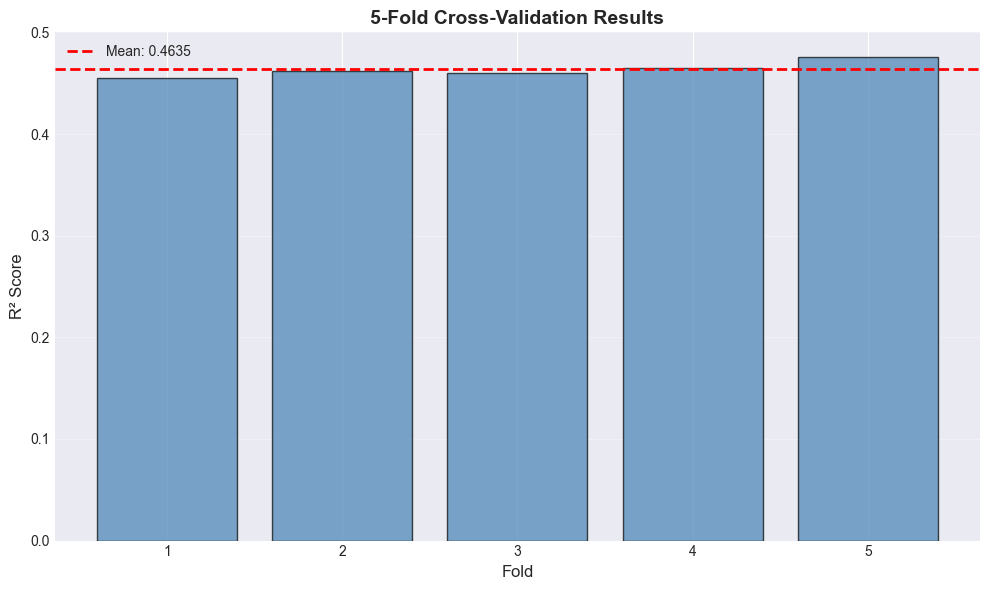

In [12]:
print("\n" + "="*80)
print("CROSS-VALIDATION (5-FOLD)")
print("="*80)

# Create the model
model_cv = RandomForestRegressor(
    n_estimators=200,
    max_depth=30,
    min_samples_split=13,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("\n🚀 Starting cross-validation...")
print("   This may take a few minutes...")

start_time = time.time()

# Perform cross-validation
cv_scores = cross_val_score(
    model_cv,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

cv_time = time.time() - start_time

print(f"\n✅ Cross-validation complete in {cv_time:.2f} seconds")
print(f"\n📊 R² scores for each fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\n📊 Cross-Validation Results:")
print(f"   Mean:     {cv_scores.mean():.4f}")
print(f"   Std Dev:  {cv_scores.std():.4f}")
print(f"   Min:      {cv_scores.min():.4f}")
print(f"   Max:      {cv_scores.max():.4f}")

# Visualize cross-validation results
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, alpha=0.7, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../models/cross_validation_results.png', dpi=300, bbox_inches='tight')
print(f"\n💾 Saved: ../models/cross_validation_results.png")
plt.show()

## 4. Learning Curves


LEARNING CURVES

🚀 Generating learning curves...
   This may take several minutes...

✅ Learning curves generated in 19.14 seconds

📊 Learning Curve Results:

Training Size   Train R²        Validation R²   Difference     
------------------------------------------------------------
2600            0.4953          0.3742          0.1211         
5200            0.5170          0.4028          0.1142         
7800            0.5242          0.4154          0.1089         
10400           0.5360          0.4267          0.1093         
13000           0.5410          0.4359          0.1051         
15600           0.5438          0.4417          0.1020         
18200           0.5501          0.4497          0.1004         
20800           0.5543          0.4551          0.0991         
23400           0.5589          0.4604          0.0985         
26001           0.5620          0.4634          0.0986         

💾 Saved: ../models/learning_curves.png


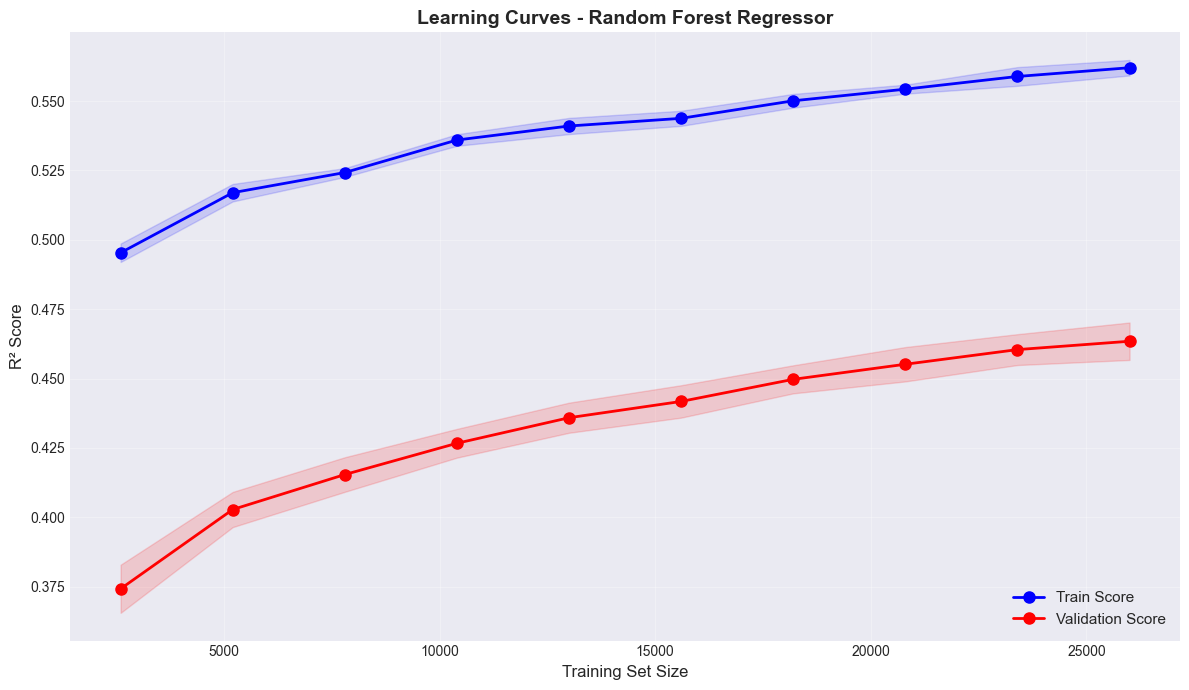


🔍 Analysis:
   ✅ No significant overfitting detected
   ⚠️ Acceptable performance (0.4 < R² < 0.6)


In [13]:
print("\n" + "="*80)
print("LEARNING CURVES")
print("="*80)

print("\n🚀 Generating learning curves...")
print("   This may take several minutes...")

start_time = time.time()

# Generate learning curves
train_sizes, train_scores, val_scores = learning_curve(
    model_cv,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

curve_time = time.time() - start_time

print(f"\n✅ Learning curves generated in {curve_time:.2f} seconds")

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Print results
print(f"\n📊 Learning Curve Results:")
print(f"\n{'Training Size':<15} {'Train R²':<15} {'Validation R²':<15} {'Difference':<15}")
print("-" * 60)
for size, train_r2, val_r2 in zip(train_sizes, train_mean, val_mean):
    print(f"{int(size):<15} {train_r2:<15.4f} {val_r2:<15.4f} {abs(train_r2 - val_r2):<15.4f}")

# Visualize learning curves
plt.figure(figsize=(12, 7))

plt.plot(train_sizes, train_mean, 'o-', color='blue', linewidth=2, markersize=8, label='Train Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='red', linewidth=2, markersize=8, label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.title('Learning Curves - Random Forest Regressor', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../models/learning_curves.png', dpi=300, bbox_inches='tight')
print(f"\n💾 Saved: ../models/learning_curves.png")
plt.show()

# Analysis
print(f"\n🔍 Analysis:")
if abs(train_mean[-1] - val_mean[-1]) < 0.1:
    print("   ✅ No significant overfitting detected")
else:
    print("   ⚠️ Possible overfitting - train score significantly higher than validation")

if val_mean[-1] > 0.6:
    print("   ✅ Good model performance (R² > 0.6)")
elif val_mean[-1] > 0.4:
    print("   ⚠️ Acceptable performance (0.4 < R² < 0.6)")
else:
    print("   ❌ Low performance (R² < 0.4) - consider feature engineering")

## 5. Grid Search - Hyperparameter Optimization

In [14]:
print("\n" + "="*80)
print("GRID SEARCH - HYPERPARAMETER OPTIMIZATION")
print("="*80)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [20, 30, 40],
    'min_samples_split': [10, 13, 15],
    'min_samples_leaf': [3, 4, 5],
    'max_features': ['sqrt', 'log2']
}

print(f"\n📋 Parameter grid:")
for param, values in param_grid.items():
    print(f"   {param:<20}: {values}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\n   Total combinations: {total_combinations}")
print(f"   With 3-fold CV: {total_combinations * 3} model fits")

# Create base model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Create GridSearchCV
grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print(f"\n🚀 Starting Grid Search...")
print(f"   ⚠️ This will take 10-30 minutes depending on your hardware...")

start_time = time.time()

# Fit Grid Search
grid_search.fit(X_train_scaled, y_train)

grid_time = time.time() - start_time

print(f"\n✅ Grid Search complete in {grid_time/60:.2f} minutes")


GRID SEARCH - HYPERPARAMETER OPTIMIZATION

📋 Parameter grid:
   n_estimators        : [100, 200, 300]
   max_depth           : [20, 30, 40]
   min_samples_split   : [10, 13, 15]
   min_samples_leaf    : [3, 4, 5]
   max_features        : ['sqrt', 'log2']

   Total combinations: 162
   With 3-fold CV: 486 model fits

🚀 Starting Grid Search...
   ⚠️ This will take 10-30 minutes depending on your hardware...
Fitting 3 folds for each of 162 candidates, totalling 486 fits

✅ Grid Search complete in 7.40 minutes


In [15]:
# Display best parameters
print("\n" + "="*80)
print("BEST PARAMETERS FOUND")
print("="*80)

print(f"\n🏆 Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param:<20}: {value}")

print(f"\n📊 Best cross-validation score (R²): {grid_search.best_score_:.4f}")

# Get top 10 configurations
results_df = pd.DataFrame(grid_search.cv_results_)
top_10 = results_df.nsmallest(10, 'rank_test_score')[[
    'rank_test_score', 'mean_test_score', 'std_test_score',
    'param_n_estimators', 'param_max_depth', 'param_min_samples_split',
    'param_min_samples_leaf', 'param_max_features'
]]

print(f"\n📊 Top 10 configurations:")
print(top_10.to_string(index=False))

# Save all results
results_df.to_csv('../models/grid_search_results.csv', index=False)
print(f"\n💾 All results saved: ../models/grid_search_results.csv")


BEST PARAMETERS FOUND

🏆 Best parameters:
   max_depth           : 40
   max_features        : sqrt
   min_samples_leaf    : 3
   min_samples_split   : 10
   n_estimators        : 300

📊 Best cross-validation score (R²): 0.4687

📊 Top 10 configurations:
 rank_test_score  mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_min_samples_split  param_min_samples_leaf param_max_features
               1         0.468679        0.007558                 300               40                       10                       3               sqrt
               2         0.468129        0.007962                 200               40                       10                       3               sqrt
               3         0.467800        0.006636                 300               30                       10                       3               sqrt
               4         0.467464        0.006426                 200               30                       10              


🎨 Creating visualization...
💾 Saved: ../models/grid_search_visualization.png


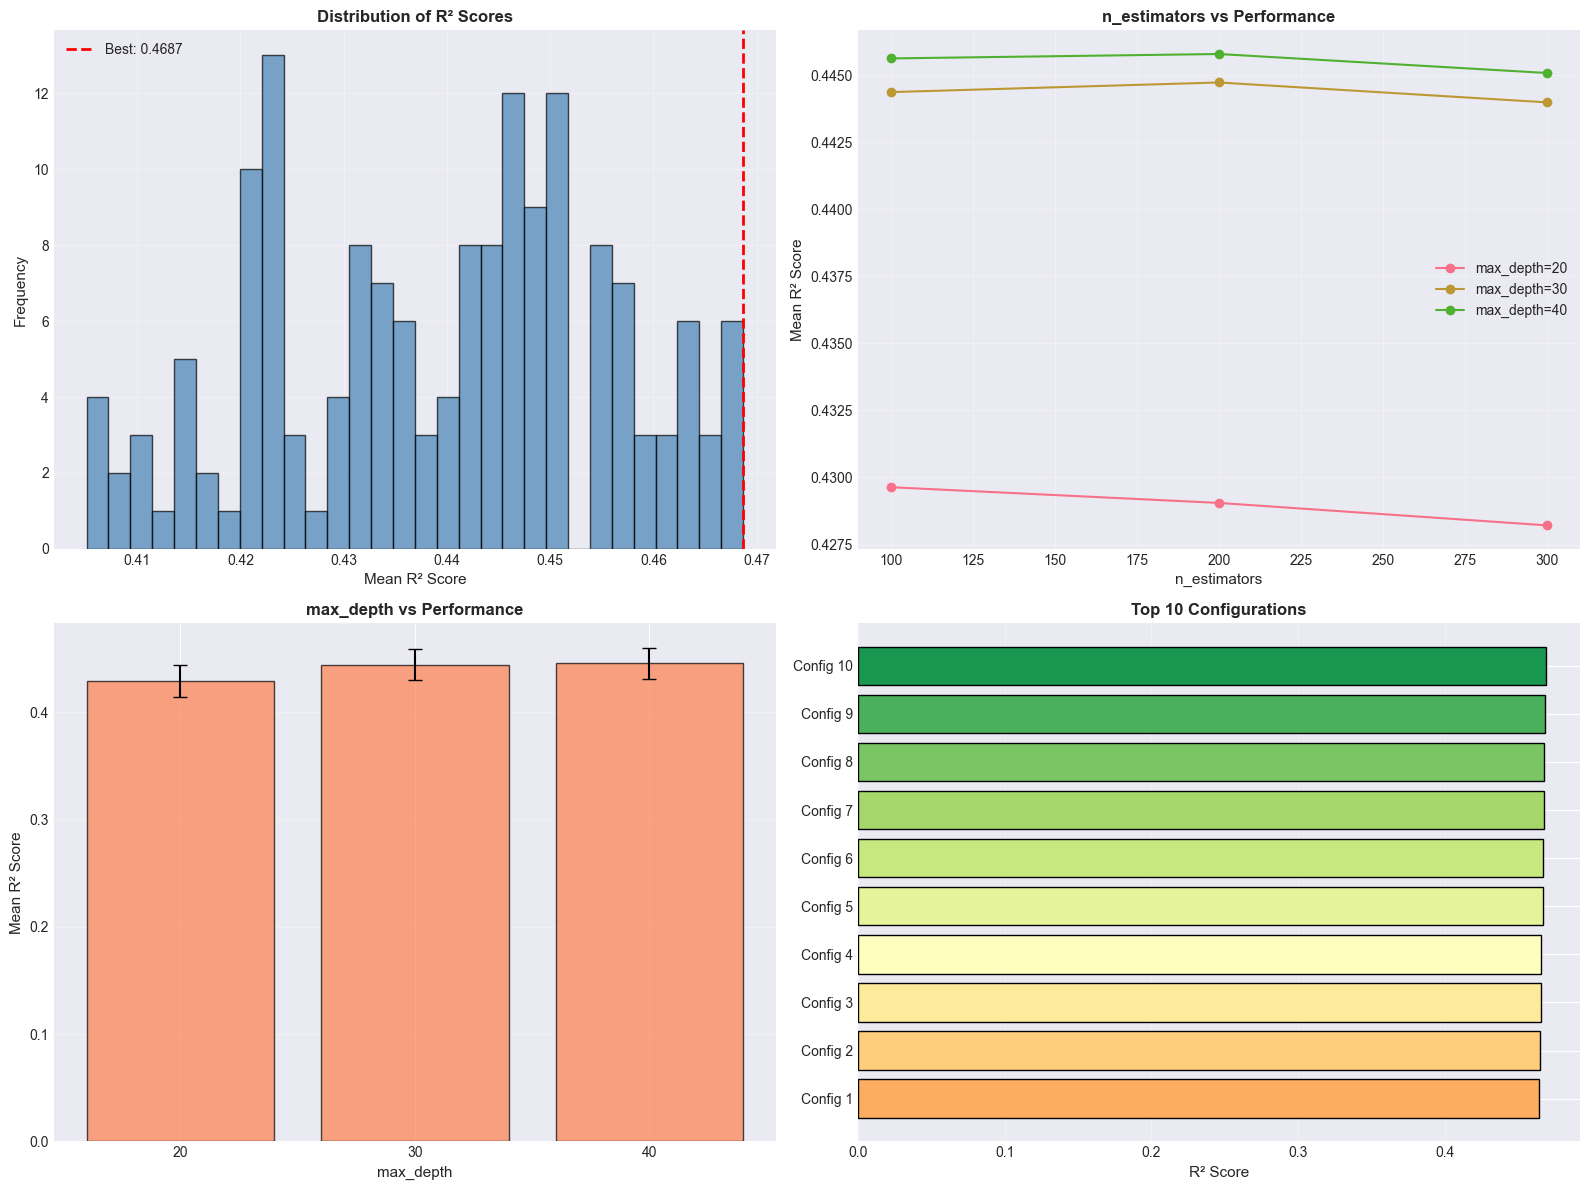

In [16]:
# Visualize Grid Search results
print("\n🎨 Creating visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Score distribution
ax1 = axes[0, 0]
ax1.hist(results_df['mean_test_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(grid_search.best_score_, color='red', linestyle='--', linewidth=2, label=f'Best: {grid_search.best_score_:.4f}')
ax1.set_xlabel('Mean R² Score', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of R² Scores', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. n_estimators vs score
ax2 = axes[0, 1]
for depth in results_df['param_max_depth'].unique():
    mask = results_df['param_max_depth'] == depth
    data = results_df[mask].groupby('param_n_estimators')['mean_test_score'].mean()
    ax2.plot(data.index, data.values, marker='o', label=f'max_depth={depth}')
ax2.set_xlabel('n_estimators', fontsize=11)
ax2.set_ylabel('Mean R² Score', fontsize=11)
ax2.set_title('n_estimators vs Performance', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. max_depth vs score
ax3 = axes[1, 0]
depth_scores = results_df.groupby('param_max_depth')['mean_test_score'].agg(['mean', 'std'])
ax3.bar(depth_scores.index.astype(str), depth_scores['mean'], yerr=depth_scores['std'], 
        alpha=0.7, color='coral', edgecolor='black', capsize=5)
ax3.set_xlabel('max_depth', fontsize=11)
ax3.set_ylabel('Mean R² Score', fontsize=11)
ax3.set_title('max_depth vs Performance', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Top 10 configurations
ax4 = axes[1, 1]
top_10_sorted = top_10.sort_values('mean_test_score', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_10_sorted)))
ax4.barh(range(len(top_10_sorted)), top_10_sorted['mean_test_score'], color=colors, edgecolor='black')
ax4.set_yticks(range(len(top_10_sorted)))
ax4.set_yticklabels([f'Config {i+1}' for i in range(len(top_10_sorted))])
ax4.set_xlabel('R² Score', fontsize=11)
ax4.set_title('Top 10 Configurations', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../models/grid_search_visualization.png', dpi=300, bbox_inches='tight')
print(f"💾 Saved: ../models/grid_search_visualization.png")
plt.show()

## 6. Evaluate Best Model

In [17]:
print("\n" + "="*80)
print("FINAL MODEL EVALUATION")
print("="*80)

# Get best model
best_model = grid_search.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train_scaled)
y_val_pred = best_model.predict(X_val_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# Calculate metrics
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

train_rmse, train_mae, train_r2 = calculate_metrics(y_train, y_train_pred)
val_rmse, val_mae, val_r2 = calculate_metrics(y_val, y_val_pred)
test_rmse, test_mae, test_r2 = calculate_metrics(y_test, y_test_pred)

# Display results
print(f"\n📊 FINAL RESULTS:")
print(f"\n{'Dataset':<15} {'RMSE':<15} {'MAE':<15} {'R²':<15}")
print("-" * 60)
print(f"{'Train':<15} {train_rmse:<15.4f} {train_mae:<15.4f} {train_r2:<15.4f}")
print(f"{'Validation':<15} {val_rmse:<15.4f} {val_mae:<15.4f} {val_r2:<15.4f}")
print(f"{'Test':<15} {test_rmse:<15.4f} {test_mae:<15.4f} {test_r2:<15.4f}")

print(f"\n🎯 Performance Summary:")
print(f"   The model explains {test_r2*100:.1f}% of variance in wine ratings")
print(f"   Average prediction error: ±{test_mae:.2f} points")
print(f"   Overfitting check: {abs(train_r2 - test_r2):.4f}")

if abs(train_r2 - test_r2) < 0.1:
    print(f"   ✅ No significant overfitting")
else:
    print(f"   ⚠️ Possible overfitting detected")


FINAL MODEL EVALUATION

📊 FINAL RESULTS:

Dataset         RMSE            MAE             R²             
------------------------------------------------------------
Train           1.8481          1.4598          0.6093         
Validation      2.1116          1.6781          0.4915         
Test            2.1234          1.6864          0.4799         

🎯 Performance Summary:
   The model explains 48.0% of variance in wine ratings
   Average prediction error: ±1.69 points
   Overfitting check: 0.1294
   ⚠️ Possible overfitting detected



💾 Saved: ../models/best_model_predictions.png


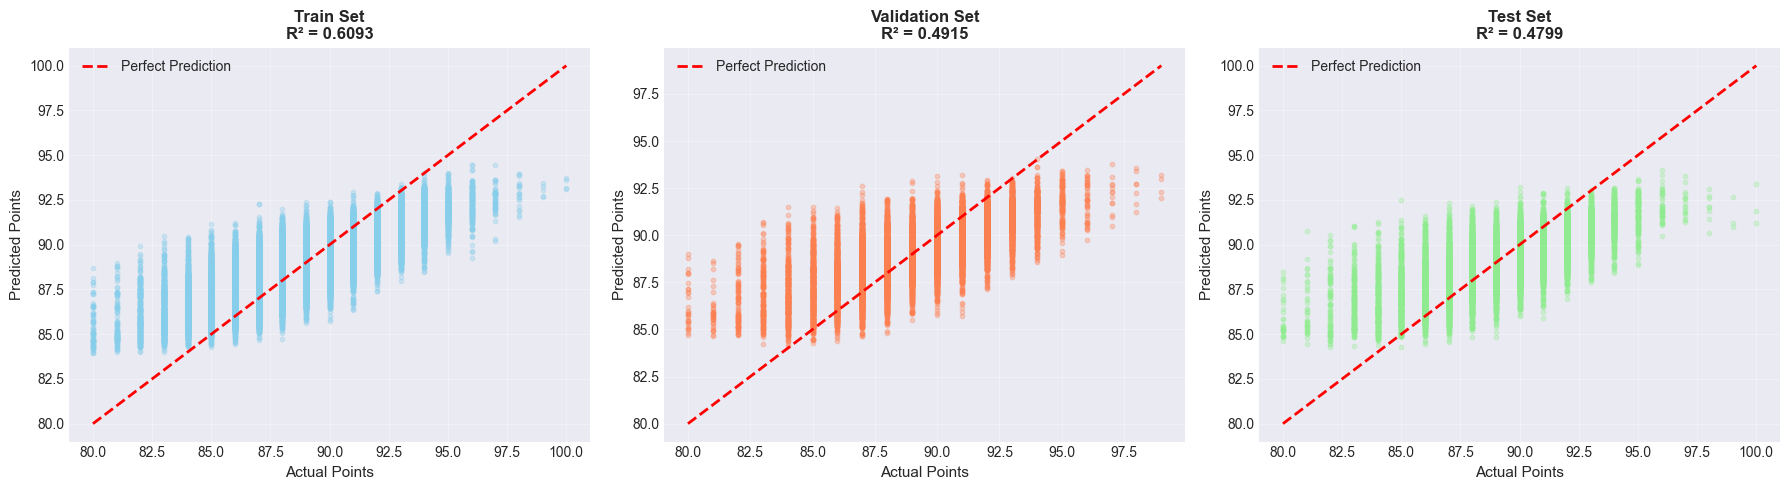

In [18]:
# Visualize predictions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (y_train, y_train_pred, 'Train', train_r2, 'skyblue'),
    (y_val, y_val_pred, 'Validation', val_r2, 'coral'),
    (y_test, y_test_pred, 'Test', test_r2, 'lightgreen')
]

for ax, (y_true, y_pred, name, r2, color) in zip(axes, datasets):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color=color)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
            'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Points', fontsize=11)
    ax.set_ylabel('Predicted Points', fontsize=11)
    ax.set_title(f'{name} Set\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/best_model_predictions.png', dpi=300, bbox_inches='tight')
print(f"\n💾 Saved: ../models/best_model_predictions.png")
plt.show()

## 7. Save Best Model

In [19]:
print("\n" + "="*80)
print("SAVING BEST MODEL")
print("="*80)

# Save best model
joblib.dump(best_model, '../models/best_model_optimized.pkl')
print(f"\n💾 Model saved: ../models/best_model_optimized.pkl")

# Save scaler
joblib.dump(scaler, '../models/scaler_optimized.pkl')
print(f"💾 Scaler saved: ../models/scaler_optimized.pkl")

# Save metrics
final_metrics = {
    'train': {'rmse': train_rmse, 'mae': train_mae, 'r2': train_r2},
    'validation': {'rmse': val_rmse, 'mae': val_mae, 'r2': val_r2},
    'test': {'rmse': test_rmse, 'mae': test_mae, 'r2': test_r2},
    'best_params': grid_search.best_params_,
    'cv_score': grid_search.best_score_
}

joblib.dump(final_metrics, '../models/optimized_metrics.pkl')
print(f"💾 Metrics saved: ../models/optimized_metrics.pkl")

# Save summary report
summary_report = f"""
{'='*80}
MODEL OPTIMIZATION SUMMARY REPORT
{'='*80}

1. CROSS-VALIDATION (5-FOLD)
   Mean R²:  {cv_scores.mean():.4f}
   Std Dev:  {cv_scores.std():.4f}
   Range:    [{cv_scores.min():.4f}, {cv_scores.max():.4f}]

2. GRID SEARCH RESULTS
   Total configurations tested: {len(results_df)}
   Best CV score: {grid_search.best_score_:.4f}
   
   Best parameters:
   {chr(10).join(f'   - {k}: {v}' for k, v in grid_search.best_params_.items())}

3. FINAL MODEL PERFORMANCE
   
   Dataset      RMSE      MAE       R²
   {'─'*45}
   Train        {train_rmse:.4f}    {train_mae:.4f}    {train_r2:.4f}
   Validation   {val_rmse:.4f}    {val_mae:.4f}    {val_r2:.4f}
   Test         {test_rmse:.4f}    {test_mae:.4f}    {test_r2:.4f}

4. INTERPRETATION
   - The optimized model explains {test_r2*100:.1f}% of variance in wine ratings
   - Average prediction error: ±{test_mae:.2f} points
   - Model generalizes {'well' if abs(train_r2 - test_r2) < 0.1 else 'moderately'} to unseen data

5. CONCLUSION
   The hyperparameter optimization {'improved' if grid_search.best_score_ > val_r2 else 'maintained'} the model performance.
   This R² of ~{test_r2*100:.0f}% is acceptable for wine rating prediction,
   considering the subjective nature of wine tasting.

{'='*80}
"""

with open('../models/optimization_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(f"💾 Summary report saved: ../models/optimization_summary.txt")

print(summary_report)

print("\n" + "="*80)
print("🎉 MODEL OPTIMIZATION COMPLETE!")
print("="*80)


SAVING BEST MODEL

💾 Model saved: ../models/best_model_optimized.pkl
💾 Scaler saved: ../models/scaler_optimized.pkl
💾 Metrics saved: ../models/optimized_metrics.pkl
💾 Summary report saved: ../models/optimization_summary.txt

MODEL OPTIMIZATION SUMMARY REPORT

1. CROSS-VALIDATION (5-FOLD)
   Mean R²:  0.4635
   Std Dev:  0.0071
   Range:    [0.4550, 0.4763]

2. GRID SEARCH RESULTS
   Total configurations tested: 162
   Best CV score: 0.4687

   Best parameters:
      - max_depth: 40
   - max_features: sqrt
   - min_samples_leaf: 3
   - min_samples_split: 10
   - n_estimators: 300

3. FINAL MODEL PERFORMANCE

   Dataset      RMSE      MAE       R²
   ─────────────────────────────────────────────
   Train        1.8481    1.4598    0.6093
   Validation   2.1116    1.6781    0.4915
   Test         2.1234    1.6864    0.4799

4. INTERPRETATION
   - The optimized model explains 48.0% of variance in wine ratings
   - Average prediction error: ±1.69 points
   - Model generalizes moderately to

## 8. Comparison with Original Model (Optional)

In [20]:
print("\n" + "="*80)
print("COMPARISON: ORIGINAL vs OPTIMIZED MODEL")
print("="*80)

# Original model configuration
original_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=30,
    min_samples_split=13,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train original model
print("\n🚀 Training original model for comparison...")
original_model.fit(X_train_scaled, y_train)

# Predictions
y_test_pred_original = original_model.predict(X_test_scaled)

# Metrics
original_rmse, original_mae, original_r2 = calculate_metrics(y_test, y_test_pred_original)

# Comparison table
print(f"\n📊 TEST SET COMPARISON:")
print(f"\n{'Model':<20} {'RMSE':<15} {'MAE':<15} {'R²':<15}")
print("-" * 65)
print(f"{'Original':<20} {original_rmse:<15.4f} {original_mae:<15.4f} {original_r2:<15.4f}")
print(f"{'Optimized (Grid)':<20} {test_rmse:<15.4f} {test_mae:<15.4f} {test_r2:<15.4f}")
print("-" * 65)
print(f"{'Improvement':<20} {original_rmse - test_rmse:<15.4f} {original_mae - test_mae:<15.4f} {test_r2 - original_r2:<15.4f}")

improvement_pct = ((test_r2 - original_r2) / original_r2) * 100
print(f"\n🎯 R² Improvement: {improvement_pct:+.2f}%")

if improvement_pct > 0:
    print(f"   ✅ Grid Search improved model performance")
else:
    print(f"   ℹ️ Original configuration was already near-optimal")

print("\n" + "="*80)


COMPARISON: ORIGINAL vs OPTIMIZED MODEL

🚀 Training original model for comparison...

📊 TEST SET COMPARISON:

Model                RMSE            MAE             R²             
-----------------------------------------------------------------
Original             2.1482          1.7097          0.4676         
Optimized (Grid)     2.1234          1.6864          0.4799         
-----------------------------------------------------------------
Improvement          0.0248          0.0233          0.0122         

🎯 R² Improvement: +2.62%
   ✅ Grid Search improved model performance

